# Debug Native-LR Spectral SDEdit SR

This notebook mirrors `debug_spectral_sdedit_logfreq.ipynb` but uses the native-LR DCT hard-embedding method. It works on one artificially degraded NLM HR validation image, uses the same NLM checkpoint by default, and still runs diagnostics up to `z_init` if the checkpoint is unavailable.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn.functional as F
from omegaconf import OmegaConf

ROOT = Path("/projects/compures/nicolas/signal_sr")
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from sr.data import build_dataloader
from sr.inference import Sampler
from sr.inference.inverter import freeze_for_inference
from sr.models import build_conditioner, build_denoiser, denoiser_conditioning_mode
from sr.objectives import Objective
from sr.schedules import build_noise_scheduler
from sr.schedules.spectral import (
    dct2,
    dct_rapsd_from_coefficients,
    estimate_hr_spectral_stats,
    hard_embed_native_lr_dct,
    idct2,
    make_dct_frequency_grid,
    native_lr_dct_proxy,
    native_lr_spectral_sdedit_init,
)
from sr.utils.checkpoints import load_model_weights
from sr.utils.config import load_config, merge_dict

torch.set_grad_enabled(False)

torch.autograd.grad_mode.set_grad_enabled(mode=False)

## User Settings

In [24]:
CONFIG_PATH = ROOT / "src/sr/configs/train/nlm_pixel_hr_linear_uncond.yaml"
CHECKPOINT_PATH = "/projects/compures/nicolas/signal_sr/runs/nlm_pixel_hr_linear_uncond/checkpoint-140000"
SPLIT = "val"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
SAMPLE_INDEX = 1
DEGRADE_MODE = "area"  # Native-LR default. Use "nearest" to match the legacy logfreq notebook exactly.
RUN_SEED_SWEEP = False
SEEDS = [42, 43, 44]

NATIVE_DEFAULTS = {
    "enabled": True,
    "transform": "dct",
    "hard_embedding": True,
    "use_lr_up": False,
    "num_log_bins": 64,
    "activation_snr": 1.0,
    "use_power_law_hr": True,
    "allow_batch_size_gt_1": False,
    "save_debug": True,
    "clip_denoised": True,
}

torch.manual_seed(SEED)
device = torch.device(DEVICE)
cfg = load_config(CONFIG_PATH)
cfg.sampling.method = "ddim"
cfg.spectral_native_lr_sdedit = OmegaConf.create(NATIVE_DEFAULTS)
image_size = int(cfg.image_size)
lr_size = int(cfg.lr_size)
out_dir = ROOT / "outputs/native_lr_spectral_sdedit_debug_nlm"
out_dir.mkdir(parents=True, exist_ok=True)
hr_stats_path = out_dir / "nlm_hr_spectral_stats.pt"
cfg

{'space': 'pixel',
 'seed': 42,
 'image_size': 128,
 'scale': 16,
 'lr_size': 8,
 'data': {'name': 'nlm',
  'root': '/projects/compures/datasets/NLM/crops',
  'split_dir': '/projects/compures/nicolas/signal_sr/data/nlm/splits/semi_biased/single/seed_2026',
  'image_size': 128,
  'scale': 8,
  'channels': 3,
  'split_strategy': 'train_hr_val_test_lr',
  'return_pair': False},
 'val_data': {'return_pair': True},
 'test_data': {'return_pair': True},
 'phase_defaults': {'train_file': 'train_pixel.py', 'infer_file': 'infer.py'},
 'denoiser': {'target': 'diffusers.UNet2DModel',
  'params': {'sample_size': 128,
   'in_channels': 3,
   'out_channels': 3,
   'layers_per_block': 2,
   'block_out_channels': [64, 128, 256, 256],
   'down_block_types': ['DownBlock2D',
    'DownBlock2D',
    'DownBlock2D',
    'AttnDownBlock2D'],
   'up_block_types': ['AttnUpBlock2D', 'UpBlock2D', 'UpBlock2D', 'UpBlock2D'],
   'dropout': 0.1,
   'norm_num_groups': 32}},
 'objective': {'name': 'diffusion', 'predictio

## Load NLM HR Validation Images And Artificially Degrade One

In [25]:
data_cfg = merge_dict(cfg.data, cfg.get(f"{SPLIT}_data", {}))
data_cfg.return_pair = True
loader = build_dataloader(data_cfg, split=SPLIT, shuffle=False, batch_size=max(SAMPLE_INDEX + 1, 1))
batch = next(iter(loader))
batch = {k: (v.to(device) if torch.is_tensor(v) else v) for k, v in batch.items()}

hr_pool = batch["hr"]
sample_idx = min(int(SAMPLE_INDEX), hr_pool.shape[0] - 1)
x_hr = hr_pool[sample_idx : sample_idx + 1]
y_lr = F.interpolate(x_hr, size=(lr_size, lr_size), mode=DEGRADE_MODE)
lr_up_ref = F.interpolate(y_lr, size=(image_size, image_size), mode="nearest")
debug_batch = dict(batch)
debug_batch.update({"image": lr_up_ref, "lr": y_lr, "lr_up": lr_up_ref, "hr": x_hr})

hr_pool.shape, y_lr.shape, lr_up_ref.shape, sample_idx

(torch.Size([2, 3, 128, 128]),
 torch.Size([1, 3, 8, 8]),
 torch.Size([1, 3, 128, 128]),
 1)

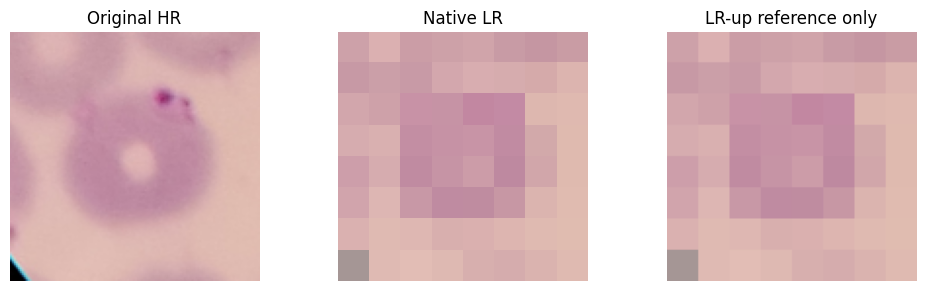

In [26]:
def image_for_plot(x, idx=0):
    img = x.detach().float().cpu()[idx]
    img = (img.clamp(-1, 1) + 1.0) / 2.0
    if img.shape[0] == 1:
        return img[0], "gray"
    return img.permute(1, 2, 0), None


def show_tensor(ax, x, title):
    img, cmap = image_for_plot(x)
    ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")


fig, axes = plt.subplots(1, 3, figsize=(10, 3))
show_tensor(axes[0], x_hr, "Original HR")
show_tensor(axes[1], y_lr, "Native LR")
show_tensor(axes[2], lr_up_ref, "LR-up reference only")
plt.tight_layout()

## HR Spectral Stats And Scheduler

In [27]:
hr_stats = estimate_hr_spectral_stats(
    [{"hr": hr_pool}],
    (image_size, image_size),
    num_log_bins=int(cfg.spectral_native_lr_sdedit["num_log_bins"]),
    save_path=hr_stats_path,
)
cfg.spectral_native_lr_sdedit.hr_stats_path = str(hr_stats_path)
{k: hr_stats[k] for k in ["beta_hr", "slope_hr", "K_hr", "H", "W", "num_log_bins", "num_images"]}

{'beta_hr': 82.45293426513672,
 'slope_hr': -2.8052520751953125,
 'K_hr': 64.0,
 'H': 128,
 'W': 128,
 'num_log_bins': 64,
 'num_images': 2}

In [28]:
noise_scheduler = build_noise_scheduler(cfg.noise_scheduler)
noise_scheduler.set_timesteps(cfg.noise_scheduler.n_infer_steps, device=device)
objective = Objective(cfg.objective, noise_scheduler)

checkpoint_path = Path(CHECKPOINT_PATH).expanduser() if CHECKPOINT_PATH else None
has_checkpoint = checkpoint_path is not None and checkpoint_path.exists()
if checkpoint_path is not None and not has_checkpoint:
    raise FileNotFoundError(f"CHECKPOINT_PATH does not exist: {checkpoint_path}")

sampler = None
denoiser = None
if has_checkpoint:
    if denoiser_conditioning_mode(cfg.denoiser) == "concat":
        raise ValueError("Native-LR Spectral SDEdit assumes no LR channel-concat conditioning.")
    denoiser = build_denoiser(cfg.denoiser, data_channels=int(cfg.data.channels)).to(device)
    conditioner = build_conditioner().to(device)
    load_model_weights(str(checkpoint_path), denoiser=denoiser, conditioner=conditioner, map_location=device)
    freeze_for_inference(denoiser, conditioner)
    sampler = Sampler(cfg.sampling, objective, noise_scheduler, denoiser, conditioner, global_cfg=cfg)

print("checkpoint:", checkpoint_path if has_checkpoint else "not provided; final reverse diffusion will be skipped")

checkpoint: /projects/compures/nicolas/signal_sr/runs/nlm_pixel_hr_linear_uncond/checkpoint-140000


## Run Native-LR Spectral SDEdit Initialization

In [29]:
def scalar(value):
    if torch.is_tensor(value):
        return float(value.detach().float().cpu().reshape(-1)[0])
    return bool(value) if isinstance(value, bool) else value


def summarize_debug(debug):
    keys = ["K_eff", "R_eff", "lambda_star", "t_star", "alpha_star", "sigma_star", "clamped_lambda"]
    return {key: scalar(debug[key]) for key in keys}


def run_once(seed=SEED, sample=True):
    torch.manual_seed(int(seed))
    z_init, t_star, debug = native_lr_spectral_sdedit_init(
        y_lr=y_lr,
        scheduler=noise_scheduler,
        hr_stats=hr_stats,
        target_hr_size=(image_size, image_size),
        activation_snr=float(cfg.spectral_native_lr_sdedit["activation_snr"]),
        allow_batch_size_gt_1=False,
    )
    x_sr = None
    if sample and sampler is not None:
        x_sr = sampler.ddim_loop_from(
            z_init.clone(),
            debug_batch,
            condition_domain="HR",
            conditioning_image=None,
            start_timestep=t_star,
            clip_denoised=bool(cfg.spectral_native_lr_sdedit["clip_denoised"]),
        )
    return {"z_init": z_init, "t_star": t_star, "debug": debug, "x_sr": x_sr, "seed": seed}


result = run_once()
summarize_debug(result["debug"])

{'K_eff': 0.519317090511322,
 'R_eff': 0.06526249647140503,
 'lambda_star': -6.250342845916748,
 't_star': 775.0,
 'alpha_star': 0.0022446324583142996,
 'sigma_star': 0.9988770484924316,
 'clamped_lambda': False}

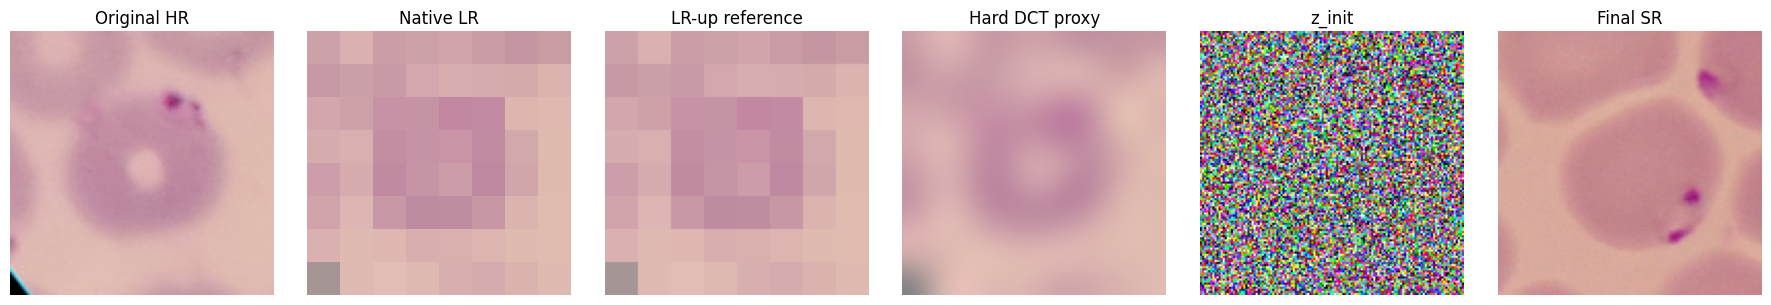

: 

In [ ]:
ncols = 6 if result["x_sr"] is not None else 5
fig, axes = plt.subplots(1, ncols, figsize=(3 * ncols, 3))
show_tensor(axes[0], x_hr, "Original HR")
show_tensor(axes[1], y_lr, "Native LR")
show_tensor(axes[2], lr_up_ref, "LR-up reference")
show_tensor(axes[3], result["debug"]["x_proxy"], "Hard DCT proxy")
show_tensor(axes[4], result["z_init"], "z_init")
if result["x_sr"] is not None:
    show_tensor(axes[5], result["x_sr"], "Final SR")
plt.tight_layout()

## Native DCT Embedding Diagnostics

In [9]:
X_emb, Y_lr = hard_embed_native_lr_dct(y_lr, (image_size, image_size))
x_proxy, _, _ = native_lr_dct_proxy(y_lr, (image_size, image_size))
gamma = (image_size * image_size / (lr_size * lr_size)) ** 0.5
support_error = (X_emb[:, :, :lr_size, :lr_size] - gamma * Y_lr).abs().max().item()
outside_support = X_emb.clone()
outside_support[:, :, :lr_size, :lr_size] = 0
{
    "gamma": gamma,
    "support_error": support_error,
    "outside_support_max_abs": outside_support.abs().max().item(),
    "proxy_l1_vs_debug": (x_proxy - result["debug"]["x_proxy"]).abs().mean().item(),
}

{'gamma': 16.0,
 'support_error': 0.0,
 'outside_support_max_abs': 0.0,
 'proxy_l1_vs_debug': 0.0}

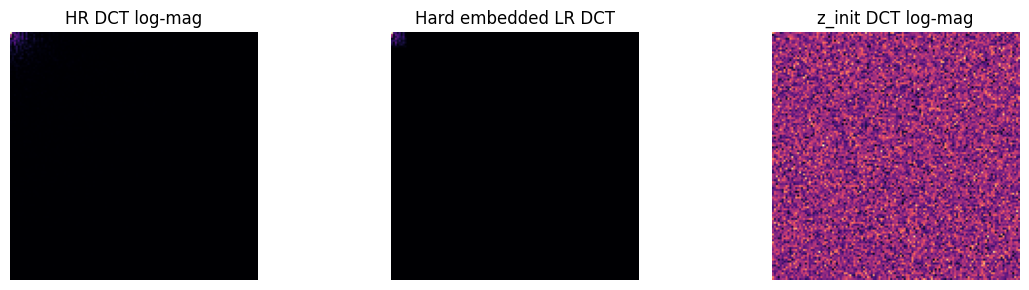

In [10]:
def log_mag(coeffs):
    values = torch.log1p(coeffs.detach().float().abs().mean(dim=1))[0].cpu()
    return values


fig, axes = plt.subplots(1, 3, figsize=(12, 3))
axes[0].imshow(log_mag(dct2(x_hr.float())), cmap="magma")
axes[0].set_title("HR DCT log-mag")
axes[0].axis("off")
axes[1].imshow(log_mag(X_emb), cmap="magma")
axes[1].set_title("Hard embedded LR DCT")
axes[1].axis("off")
axes[2].imshow(log_mag(dct2(result["z_init"].float())), cmap="magma")
axes[2].set_title("z_init DCT log-mag")
axes[2].axis("off")
plt.tight_layout()

## Spectral Power, q-Bins, K_eff, And t_star

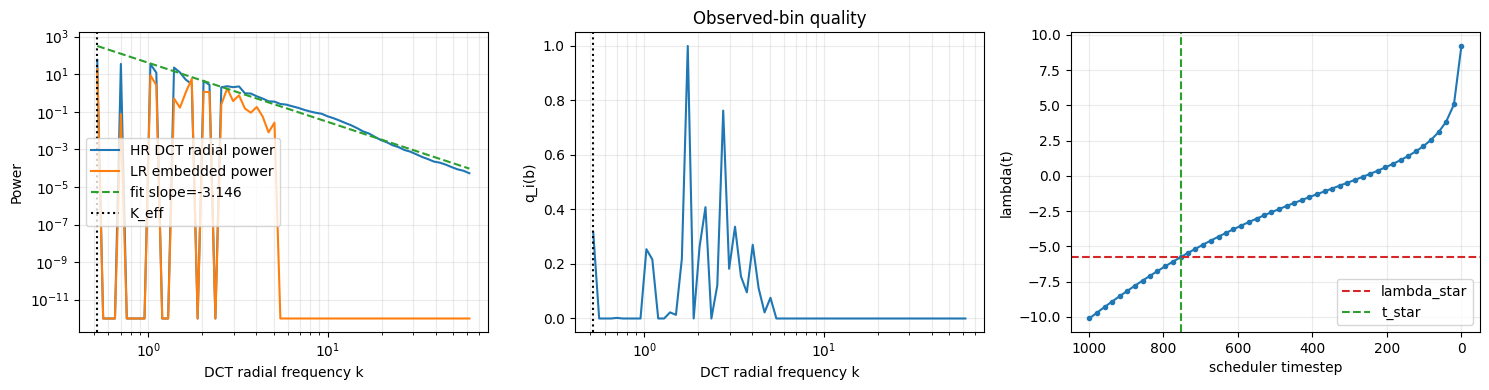

In [11]:
centers = hr_stats["bin_centers"].float()
P_hr = hr_stats["P_hr_bins"].float()
fit = hr_stats["beta_hr"] * centers.clamp_min(1e-8).pow(hr_stats["slope_hr"])
E_lr = result["debug"]["E_bins"][0].detach().cpu().float()
q_bins = result["debug"]["q_bins"][0].detach().cpu().float()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].loglog(centers, P_hr.clamp_min(1e-12), label="HR DCT radial power")
axes[0].loglog(centers, E_lr.clamp_min(1e-12), label="LR embedded power")
axes[0].loglog(centers, fit.clamp_min(1e-12), "--", label=f"fit slope={hr_stats['slope_hr']:.3f}")
axes[0].axvline(float(result["debug"]["K_eff"][0].cpu()), color="k", linestyle=":", label="K_eff")
axes[0].set_xlabel("DCT radial frequency k")
axes[0].set_ylabel("Power")
axes[0].legend()
axes[0].grid(True, which="both", alpha=0.25)

axes[1].semilogx(centers, q_bins)
axes[1].axvline(float(result["debug"]["K_eff"][0].cpu()), color="k", linestyle=":")
axes[1].set_ylim(-0.05, 1.05)
axes[1].set_xlabel("DCT radial frequency k")
axes[1].set_ylabel("q_i(b)")
axes[1].set_title("Observed-bin quality")
axes[1].grid(True, which="both", alpha=0.25)

lambdas = noise_scheduler.logsnr(noise_scheduler.timesteps).detach().cpu()
axes[2].plot(noise_scheduler.timesteps.detach().cpu(), lambdas, marker="o", ms=3)
axes[2].axhline(float(result["debug"]["lambda_star"][0].cpu()), color="tab:red", linestyle="--", label="lambda_star")
axes[2].axvline(float(result["t_star"][0].cpu()), color="tab:green", linestyle="--", label="t_star")
axes[2].invert_xaxis()
axes[2].set_xlabel("scheduler timestep")
axes[2].set_ylabel("lambda(t)")
axes[2].legend()
axes[2].grid(True, alpha=0.25)
plt.tight_layout()

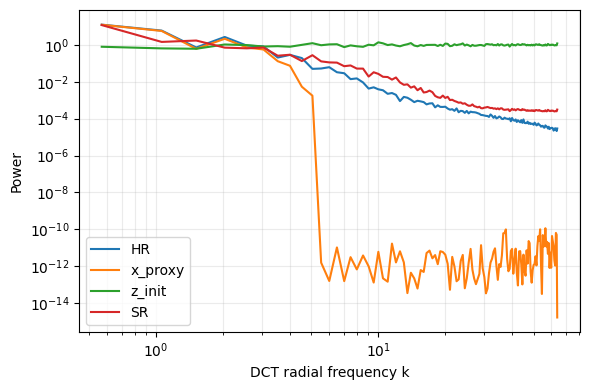

In [12]:
plt.figure(figsize=(6, 4))
for image, label in [
    (x_hr, "HR"),
    (result["debug"]["x_proxy"], "x_proxy"),
    (result["z_init"], "z_init"),
]:
    kk, pp = dct_rapsd_from_coefficients(dct2(image.float()))
    plt.loglog(kk.cpu(), pp[0].cpu(), label=label)
if result["x_sr"] is not None:
    kk, pp = dct_rapsd_from_coefficients(dct2(result["x_sr"].float()))
    plt.loglog(kk.cpu(), pp[0].cpu(), label="SR")
plt.xlabel("DCT radial frequency k")
plt.ylabel("Power")
plt.legend()
plt.grid(True, which="both", alpha=0.25)
plt.tight_layout()

## Constant-Image Check

{'constant_embedding_max_abs_error': 3.5762786865234375e-07}


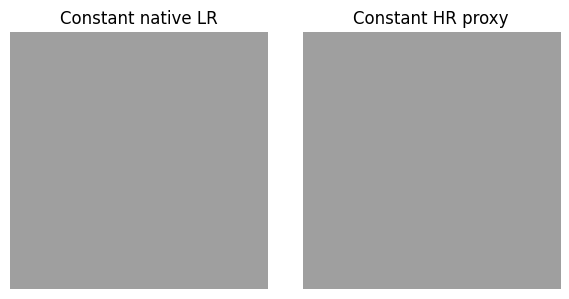

In [13]:
constant_lr = torch.full_like(y_lr, 0.25)
constant_proxy, _, _ = native_lr_dct_proxy(constant_lr, (image_size, image_size))
max_abs_error = (constant_proxy - 0.25).abs().max().item()
print({"constant_embedding_max_abs_error": max_abs_error})

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_tensor(axes[0], constant_lr, "Constant native LR")
show_tensor(axes[1], constant_proxy, "Constant HR proxy")
plt.tight_layout()

## Optional Seed Sweep And Debug Files

In [14]:
records = []
main_record = {
    "image_id": int(batch.get("sample_id", torch.tensor([sample_idx], device=device))[sample_idx].detach().cpu())
    if "sample_id" in batch
    else int(sample_idx),
    **summarize_debug(result["debug"]),
}
records.append(main_record)

if RUN_SEED_SWEEP and sampler is not None:
    seed_results = []
    for seed in SEEDS:
        out = run_once(seed=seed, sample=True)
        seed_results.append(out)
        records.append({"image_id": int(sample_idx), "seed": int(seed), **summarize_debug(out["debug"])})

    fig, axes = plt.subplots(1, len(seed_results), figsize=(3 * len(seed_results), 3))
    if len(seed_results) == 1:
        axes = [axes]
    for ax, out in zip(axes, seed_results):
        show_tensor(ax, out["x_sr"], f"seed={out['seed']}")
    plt.tight_layout()
elif RUN_SEED_SWEEP:
    print("RUN_SEED_SWEEP=True but checkpoint/sampler is unavailable.")

jsonl_path = out_dir / "per_image_native_lr_spectral_sdedit_stats.jsonl"
with jsonl_path.open("w", encoding="utf-8") as handle:
    for record in records:
        handle.write(json.dumps(record) + "\n")

summary = {
    "config_path": str(CONFIG_PATH),
    "checkpoint_path": str(checkpoint_path) if checkpoint_path is not None else None,
    "has_checkpoint": bool(has_checkpoint),
    "split": SPLIT,
    "sample_index": int(sample_idx),
    "degrade_mode": DEGRADE_MODE,
    "hr_stats_path": str(hr_stats_path),
    "num_records": len(records),
    "main_record": main_record,
}
summary_path = out_dir / "native_lr_spectral_sdedit_summary.json"
with summary_path.open("w", encoding="utf-8") as handle:
    json.dump(summary, handle, indent=2)

pd.DataFrame(records), jsonl_path, summary_path

(   image_id     K_eff     R_eff  lambda_star  t_star  alpha_star  sigma_star  \
 0       354  0.519317  0.075765    -5.756242   754.0    0.003105    0.998446   
 
    clamped_lambda  
 0           False  ,
 PosixPath('/projects/compures/nicolas/signal_sr/outputs/native_lr_spectral_sdedit_debug_nlm/per_image_native_lr_spectral_sdedit_stats.jsonl'),
 PosixPath('/projects/compures/nicolas/signal_sr/outputs/native_lr_spectral_sdedit_debug_nlm/native_lr_spectral_sdedit_summary.json'))